In [195]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import yaml
import csv
from Bio import SeqIO

from collections import Counter

from pathlib import Path

In [196]:
NOTEBOOK_DIR: Path = Path.cwd()
PROJECT_ROOT: Path = NOTEBOOK_DIR.parent
CONFIG_PATH: Path = PROJECT_ROOT / "config" / "blast.yml"

with open(CONFIG_PATH, "r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

MERGED_SPECIFICATION = PROJECT_ROOT / (config["paths"]["specification_csv"])
AMPLICON_SPECIFICATION = PROJECT_ROOT / (config["paths"]["amplicon_specification_csv"])
FASTA_INPUT = PROJECT_ROOT / (config["paths"]["fasta_input"])
ASSAYBLAST_SEPCIFICATION = PROJECT_ROOT / (config["paths"]["assayblast_specification_csv"])
ASSAYBLAST_DETAILS = PROJECT_ROOT / (config["paths"]["assay_details"])

In [197]:
accessions = []
with open(str(FASTA_INPUT)) as in_handle:
    for record in SeqIO.parse(in_handle, "fasta"):
        accessions.append(record.id)

# print(len(accessions))


# df_amplicon = pd.read_csv(amplicon_csv)
# passed_accessions = []
# for index, row in df_amplicon.iterrows():
#     if float(row['Percent of passed amplicons']) > 0:
#         passed_accessions.append(row['Accession'])

    
df_merged = pd.read_csv(MERGED_SPECIFICATION)
passed_rows = []
passed_accessions = []

for index, row in df_merged.iterrows():
    if row['accession'] in accessions:
        passed_rows.append(row)
        passed_accessions.append(row['accession'])

# print(len(passed_rows))
# print(len(passed_accessions))

# # print(passed_rows[0]['accession'])
# for seq in accessions:
#     if seq not in passed_accessions:
#         print(seq)

count = Counter(accessions)
for element, nmbr in count.items():
    if nmbr > 1: 
        print(element, nmbr)



df_new = pd.DataFrame(passed_rows, columns=df_merged.columns) 
df_new.to_csv(ASSAYBLAST_SEPCIFICATION, index = False)

In [198]:
assayblast_spec_df = pd.read_csv(ASSAYBLAST_SEPCIFICATION)
assayblast_spec_df.head(10)

,accession,BLAST_score,begin,end,length,p_type,p_subtype,rdrp_start,rdrp_end,rdrp_source,genotype,genotype_subtype,vp1_start,vp1_end,has_overlap,overlap
0,PV784273.1,75.859245,0.0,7549.0,7555.0,GII.P17,NaN,3581.0,5110.0,annotated_rdrp,GII.17,NaN,5094.0,6710.0,True,17.0
1,PV784272.1,75.941080,0.0,7549.0,7555.0,GII.P17,NaN,3581.0,5110.0,annotated_rdrp,GII.17,NaN,5094.0,6710.0,True,17.0
2,PX285874.1,75.855860,0.0,7573.0,7567.0,GII.P16,NaN,3572.0,5101.0,annotated_rdrp,GII.4,Sydney_2016,5085.0,6707.0,True,17.0
3,PX285872.1,76.411850,0.0,7538.0,7538.0,GII.P16,NaN,3572.0,5101.0,annotated_rdrp,GII.2,NaN,5085.0,6713.0,True,17.0
4,PX631121.1,75.708435,0.0,7576.0,7570.0,GII.P16,NaN,3572.0,5101.0,annotated_rdrp,GII.4,Sydney_2016,5085.0,6707.0,True,17.0
5,GU292831.4,76.530880,0.0,7550.0,7577.0,GII.P16,NaN,3566.0,5095.0,annotated_rdrp,GII.16,NaN,5079.0,6701.0,True,17.0
6,HM596590.4,75.442320,0.0,7524.0,7536.0,GII.P16,NaN,3569.0,5098.0,annotated_rdrp,GII.5,NaN,5082.0,6704.0,True,17.0
7,KF895841.2,76.348970,1.0,7555.0,7551.0,GII.P16,NaN,3500.0,5100.0,polyprotein_fallback,GII.3,NaN,5081.0,6727.0,True,20.0
8,KT779557.1,76.168070,0.0,7552.0,7549.0,GII.P16,NaN,3500.0,5101.0,polyprotein_fallback,GII.3,NaN,5082.0,6728.0,True,20.0
9,KX586330.1,85.238335,4.0,7519.0,7509.0,GII.P31,NaN,3500.0,5100.0,polyprotein_fallback,GII.4,Sydney_2012,5081.0,6703.0,True,20.0


In [199]:
amplicon_spec_df = pd.read_csv(AMPLICON_SPECIFICATION)
amplicon_spec_df.head(10)

,accession,BLAST_score,begin,end,length,p_type,p_subtype,rdrp_start,rdrp_end,rdrp_source,genotype,genotype_subtype,vp1_start,vp1_end,has_overlap,overlap
0,PV784273.1,75.859245,0.0,7549.0,7555.0,GII.P17,NaN,3581.0,5110.0,annotated_rdrp,GII.17,NaN,5094.0,6710.0,True,17.0
1,PV784272.1,75.941080,0.0,7549.0,7555.0,GII.P17,NaN,3581.0,5110.0,annotated_rdrp,GII.17,NaN,5094.0,6710.0,True,17.0
2,PX285874.1,75.855860,0.0,7573.0,7567.0,GII.P16,NaN,3572.0,5101.0,annotated_rdrp,GII.4,Sydney_2016,5085.0,6707.0,True,17.0
3,PX285872.1,76.411850,0.0,7538.0,7538.0,GII.P16,NaN,3572.0,5101.0,annotated_rdrp,GII.2,NaN,5085.0,6713.0,True,17.0
4,PX631121.1,75.708435,0.0,7576.0,7570.0,GII.P16,NaN,3572.0,5101.0,annotated_rdrp,GII.4,Sydney_2016,5085.0,6707.0,True,17.0
5,GU292831.4,76.530880,0.0,7550.0,7577.0,GII.P16,NaN,3566.0,5095.0,annotated_rdrp,GII.16,NaN,5079.0,6701.0,True,17.0
6,HM596590.4,75.442320,0.0,7524.0,7536.0,GII.P16,NaN,3569.0,5098.0,annotated_rdrp,GII.5,NaN,5082.0,6704.0,True,17.0
7,KF895841.2,76.348970,1.0,7555.0,7551.0,GII.P16,NaN,3500.0,5100.0,polyprotein_fallback,GII.3,NaN,5081.0,6727.0,True,20.0
8,KT779557.1,76.168070,0.0,7552.0,7549.0,GII.P16,NaN,3500.0,5101.0,polyprotein_fallback,GII.3,NaN,5082.0,6728.0,True,20.0
9,KX586330.1,85.238335,4.0,7519.0,7509.0,GII.P31,NaN,3500.0,5100.0,polyprotein_fallback,GII.4,Sydney_2012,5081.0,6703.0,True,20.0


In [200]:
sns.set(rc={"figure.figsize":(16, 7)})

In [201]:
# assayblast_spec_df.sort_values(by="p_type", inplace=True)
# sns.countplot(x="p_type", data=assayblast_spec_df)
# plt.xticks(rotation=45, ha='right')
# plt.title("all p-types controlled in assayblast")
# plt.show()

In [202]:
# amplicon_spec_df.sort_values(by="p_type", inplace=True)
# sns.countplot(x="p_type", data=amplicon_spec_df)
# plt.xticks(rotation=45, ha='right')
# #plt.title("all p-types with correct amplicons")


# assayblast_spec_df.sort_values(by="p_type", inplace=True)
# sns.countplot(x="p_type", data=assayblast_spec_df)
# plt.xticks(rotation=45, ha='right')
# plt.title("all p-types controlled in assayblast")

# #x = np.arange(len(labels))
# #width = 0.35







# plt.show()

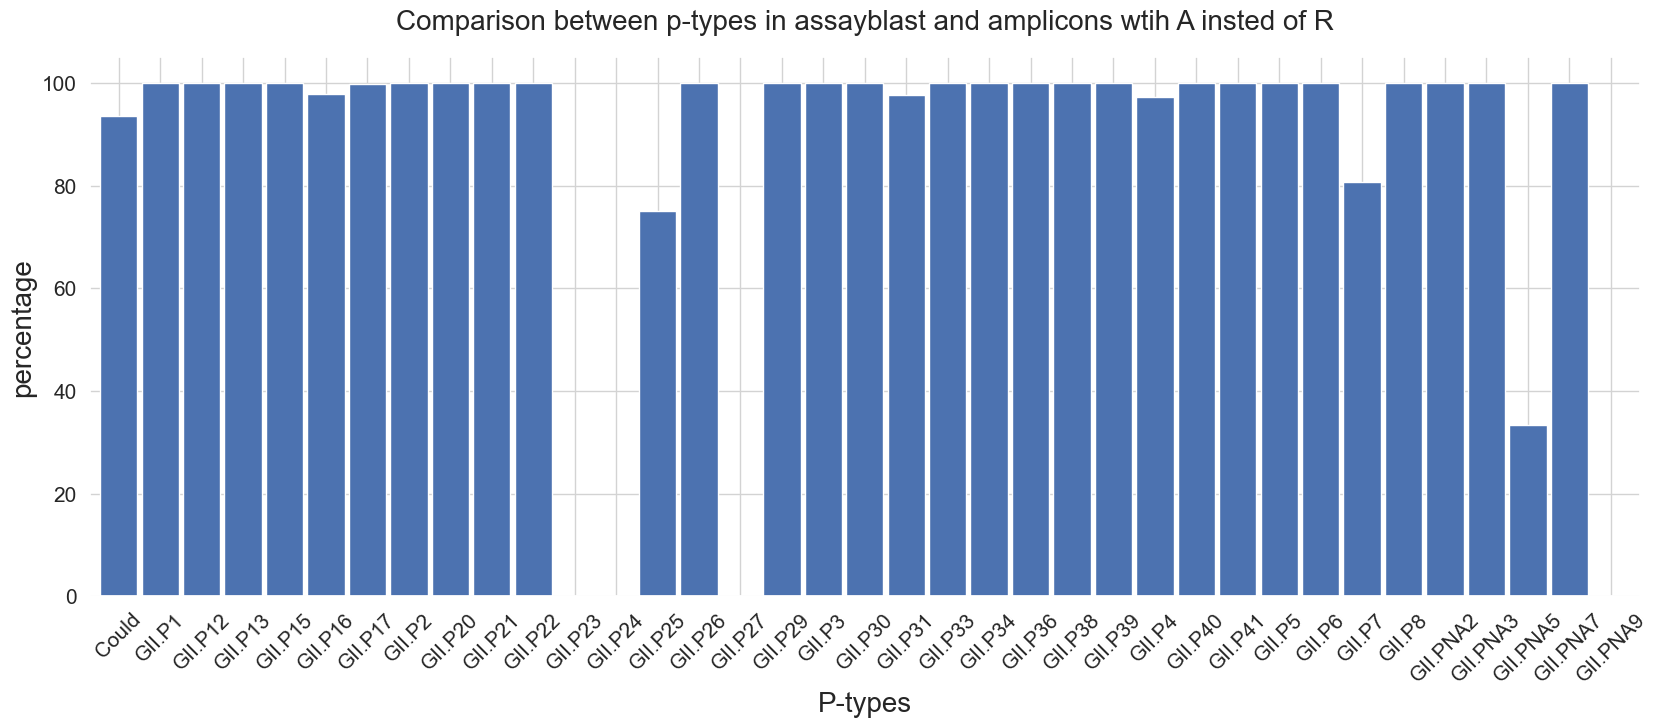

In [203]:
# Läs in dina CSV-filer
amplicon_spec_df.sort_values(by="p_type", inplace=True)
assayblast_spec_df.sort_values(by="p_type", inplace=True)

# Räkna förekomster av varje värde i kolumnen
counts1 = amplicon_spec_df["p_type"].value_counts()
counts2 = assayblast_spec_df["p_type"].value_counts()

# Slå ihop till en gemensam DataFrame så x-värdena stämmer överens
combined = pd.DataFrame({
    "assayblast": (counts1/counts2)*100,
    # "amplicons": counts1
}).fillna(0)  # Om ett värde saknas i en fil, sätt 0

# Plotta grupperat stapeldiagram

combined.plot(kind="bar", figsize=(20,7), width= 0.9)
plt.title("Comparison between p-types in assayblast and amplicons wtih A insted of R",fontsize=20, pad=20)
plt.xlabel("P-types", fontsize=20)
plt.ylabel("Percent (%)", fontsize=20)
plt.xticks(rotation=45,fontsize=15)
plt.yticks(fontsize=15)
plt.legend().remove()
plt.gca().set_facecolor("white")
plt.tick_params(left=False, bottom=True)
plt.grid(color='lightgrey')
# plt.tight_layout()
plt.show()


In [204]:
# assayblast_spec_df.sort_values(by="genotype", inplace=True)
# sns.countplot(x="genotype", data=assayblast_spec_df)
# plt.xticks(rotation=45, ha='right')
# plt.title("all genotypes controlled in assayblast")
# plt.show()

/var/folders/6r/00pkvj9d6c5_pzqw26ck9pfc0000gn/T/ipykernel_3831/4152664393.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


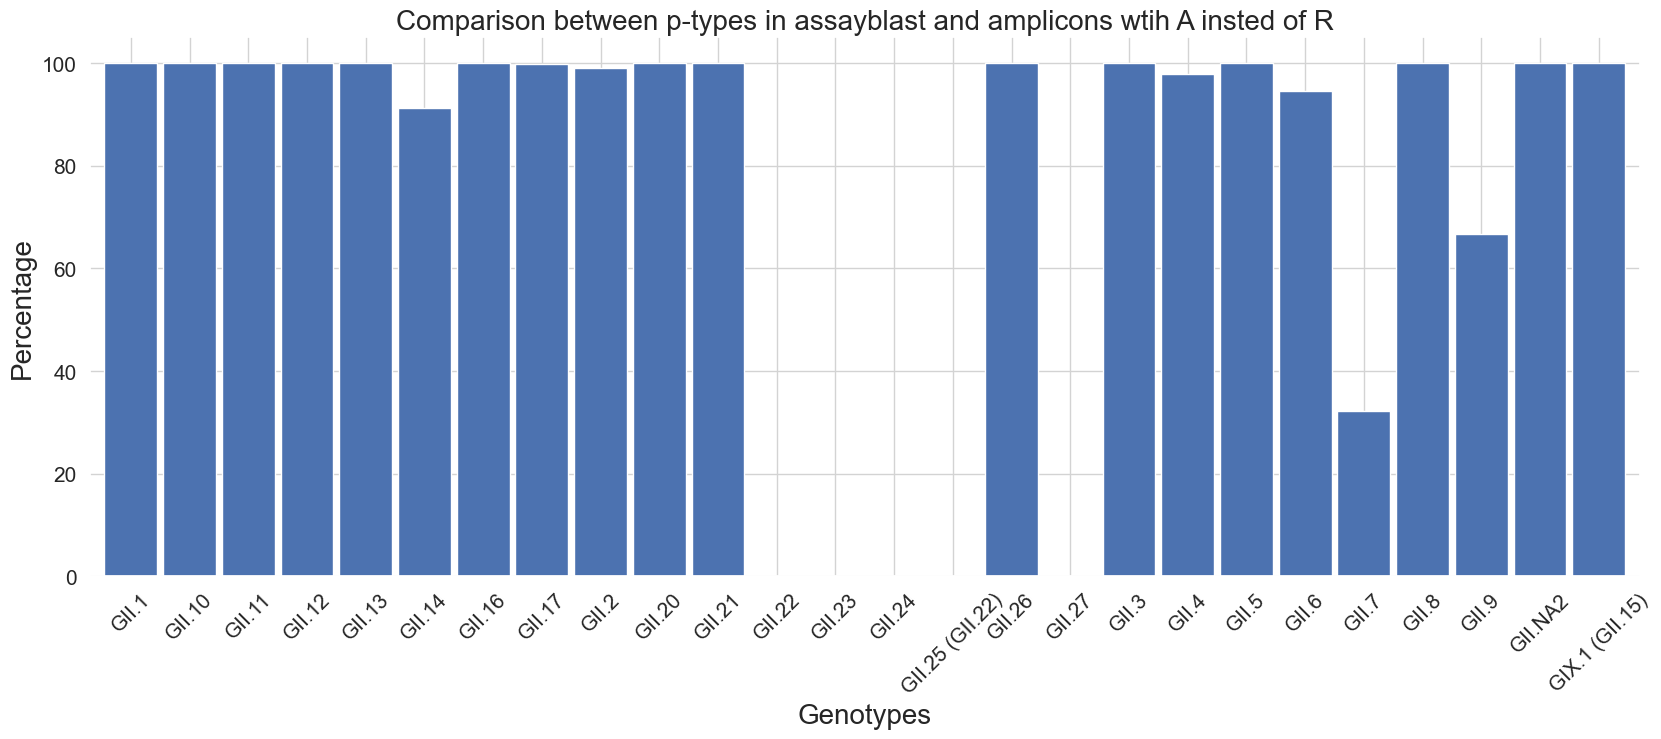

In [205]:
# Läs in dina CSV-filer
amplicon_spec_df.sort_values(by="genotype", inplace=True)
assayblast_spec_df.sort_values(by="genotype", inplace=True)

# Räkna förekomster av varje värde i kolumnen
counts1 = amplicon_spec_df["genotype"].value_counts()
counts2 = assayblast_spec_df["genotype"].value_counts()

# Slå ihop till en gemensam DataFrame så x-värdena stämmer överens
combined = pd.DataFrame({
    "": (counts1/counts2)*100,
    # "amplicons": counts1
}).fillna(0)  # Om ett värde saknas i en fil, sätt 0

# Plotta grupperat stapeldiagram

combined.plot(kind="bar", figsize=(20,7), width= 0.9)
plt.title("Comparison between p-types in assayblast and amplicons wtih A insted of R",fontsize=20)
plt.xlabel("Genotypes", fontsize=20)
plt.ylabel("Percent (%)", fontsize=20)
plt.xticks(rotation=45,fontsize=15)
plt.yticks(fontsize=15)
plt.legend().remove()
plt.gca().set_facecolor("white")
plt.grid(color='lightgrey')
plt.tick_params(left=False, bottom=True)
#plt.tight_layout()
plt.show()

In [60]:
forward_dict = {}
reverse_dict = {}
## keys = alla primers
## values = lista med acession numbers


detials_df = pd.read_csv(ASSAYBLAST_DETAILS, sep="\t")


## för att skapa tabell för primer bindning som resulterar i korrekta amplikon
for index, row in detials_df.iterrows():
    
    if row['Strand check'] == 'pass' and row['Amplification'] == 'exp' and row['Strand direction'] == '+-' and len(row['Distance']) > 1 and int(row['Distance'][1:]) > 600 and int(row['Distance'][1:]) < 900:
        primer1, primer2 = row["Pairing and Strand direction ((+)/(-))"].split(',')
        primer1 = primer1[:-4]
        primer2 = primer2[:-4]

        if primer1 not in forward_dict:
            forward_dict[primer1] = {row["Genome"]}
        else:
            forward_dict[primer1].add(row["Genome"])
        
        if primer2 not in reverse_dict:
            reverse_dict[primer2] = {row["Genome"]}
        else:
            reverse_dict[primer2].add(row["Genome"])

# print(forward_dict)
# print(reverse_dict)
# for key, value in reverse_dict.items():
#     print(key)
#     print(value)

genotype_dict = {}
p_type_dict = {}

translation = {}
used_genomes = set()
for value_set in reverse_dict.values():
    used_genomes.update(value_set)

for index, row in df_merged.iterrows():
    if row['accession'] in used_genomes:
        translation[row['accession']] = [row['genotype'], row['p_type']]

for key, value_set in reverse_dict.items():
    translated_genotype = {
        translation[v][0] for v in value_set if v in translation
    }
    translated_p_type = {
        translation[v][1] for v in value_set if v in translation
    }

    genotype_dict[key] = translated_genotype
    p_type_dict[key] = translated_p_type


# print(genotype_dict)
# print(p_type_dict)

new_dict = {
    key: sorted(
        (v for v in values if isinstance(v, str))
    )
    for key, values in genotype_dict.items()
}
print(new_dict)

detials_df.head(1)

    
    


{'reverse_primer_var3': ['GII.1', 'GII.10', 'GII.11', 'GII.12', 'GII.13', 'GII.14', 'GII.16', 'GII.17', 'GII.2', 'GII.20', 'GII.21', 'GII.3', 'GII.4', 'GII.5', 'GII.6', 'GII.7', 'GII.8', 'GII.9', 'GIX.1 (GII.15)'], 'reverse_primer_var5': ['GII.1', 'GII.10', 'GII.11', 'GII.12', 'GII.13', 'GII.14', 'GII.16', 'GII.17', 'GII.2', 'GII.20', 'GII.21', 'GII.26', 'GII.3', 'GII.4', 'GII.5', 'GII.6', 'GII.7', 'GII.8', 'GII.9', 'GII.NA2', 'GIX.1 (GII.15)'], 'reverse_primer_var7': ['GII.1', 'GII.10', 'GII.11', 'GII.12', 'GII.13', 'GII.14', 'GII.16', 'GII.17', 'GII.2', 'GII.20', 'GII.21', 'GII.3', 'GII.4', 'GII.5', 'GII.6', 'GII.7', 'GII.8', 'GII.9', 'GIX.1 (GII.15)'], 'reverse_primer_var8': ['GII.1', 'GII.10', 'GII.12', 'GII.13', 'GII.14', 'GII.16', 'GII.17', 'GII.2', 'GII.20', 'GII.21', 'GII.22', 'GII.3', 'GII.4', 'GII.5', 'GII.6', 'GII.7', 'GII.8', 'GII.9', 'GIX.1 (GII.15)'], 'reverse_primer_var1': ['GII.1', 'GII.10', 'GII.11', 'GII.12', 'GII.13', 'GII.14', 'GII.17', 'GII.2', 'GII.20', 'GII.21', 

,Genome,Primer,Amplification,Pairing and Strand direction ((+)/(-)),Strand direction,Strand check,Mismatch,Distance,Location
0,PZ221915.1,"forward_primer_var1,reverse_primer_var3",exp,"forward_primer_var1 (+),reverse_primer_var3 (-)",+-,pass,"M1,3",D797,"4595:4617:+,5415:5433:-"
